## Rubric

Instructions: DELETE this cell before you submit via a `git push` to your repo before deadline. This cell is for your reference only and is not needed in your report. 

 Scoring: Out of 10 points

- Each Developing  => -2 pts
- Each Unsatisfactory/Missing => -4 pts
  - until the score is 0

If students address the detailed feedback in a future checkpoint they will earn these points back






|                                  | **Unsatisfactory**                                                                                                                                                                                                                                                                                                                        | **Developing**                                                                                                                                                                                                       | **Proficient**                                                                                                                                                                                            | **Excellent**                                                                                                                                                                            |
|----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **EDA relevance**                | EDA is mostly neither relevant to the question nor helpful in figuring out how to address the question. Or the EDA does address the question, but many obviously relevant variables / analyses / figures were not included. | EDA is partly irrelevant/unhelpful. EDA missed one or two obvioulsy relevant analysis (distributions of single variables or relationships between variables) | EDA includes the obviously relevant / helpful variables in addressing the question.                                                              | Thorough EDA fully explored the dataset                                                                                                                 |
| **EDA analysis and description** | Many of the analyses are poor choices (e.g., using means instead of medians for obviously skewed data), or are poorly described in the text, or do not aid understanding the data                                                                                                                                                     | Some of the analyses are poor choices, or are poorly described in the text, or do not aid understanding the data                                                                                                 | All analyses are correct choices. Only one or two have minor issues in the text descriptions supporting them. Mostly they fit well with other elements of the EDA and support understanding the data  | All analyses are correct choices with clear text descriptions supporting them. The figures fit well with the other elements of the EDA, producing a clear understanding of the data. |
| **EDA figures**                  | Many of the figures are poor plot choices (e.g., using a bar plot to represent a time series where it would be better to use a line plot) or have poor aesthetics (including colormap, data point shape/color, axis labels, titles, annotations, text legibility) or do not aid understanding the data                                | Some of the figures are poor plot choices or have poor aesthetics. Some figures do not aid understanding the data                                                                                                | All figures are correct plot choices. Only one or two have minor questionable aesthetic choices. The figures mostly fit well with the other elements of the EDA and support understanding the data    | All figures are correct plot choices with beautiful aesthetics. The figures fit well with the other elements of the EDA, producing a clear understanding of the data.                |





# COGS 108 - EDA Checkpoint

## Authors

Ja-Chan Lu: Added commentary on why heights were suspicious + added data visualizations for distributions of various variables as well as missing data.

Tianlin Situ:

Julian Luan:

Tony Zhang:

## Data

### Data overview

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your data checkpoint feedback


In [ ]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [1]:
# Setup + reproducible data pull / wrangling scaffold

import os
import time
import warnings
import numpy as np
import pandas as pd

try:
    from nba_api.stats.endpoints import leaguedashplayerstats, playerindex
except ImportError as exc:
    raise ImportError("Missing dependency `nba_api` in the active notebook kernel.") from exc

warnings.filterwarnings("ignore", category=FutureWarning)

SEASONS = [
    "1996-97", "1999-00", "2004-05", "2008-09", "2012-13", "2016-17", "2020-21", "2023-24"
]
REQUEST_TIMEOUT = 120
MAX_RETRIES = 4
BASE_BACKOFF_SECONDS = 2


def season_to_era(season: str) -> str:
    start_year = int(season.split("-")[0])
    if 1990 <= start_year <= 2000:
        return "1990-2000"
    if 2001 <= start_year <= 2013:
        return "2001-2013"
    return "2014-present"


def parse_height_to_inches(height_value):
    if pd.isna(height_value):
        return np.nan
    if isinstance(height_value, (int, float)):
        return float(height_value)

    s = str(height_value).strip().replace('"', "")
    if "-" in s:
        feet, inches = s.split("-", 1)
        if feet.isdigit() and inches.isdigit():
            return int(feet) * 12 + int(inches)

    try:
        return float(s)
    except ValueError:
        return np.nan


def standardize_position(position_value) -> str:
    if pd.isna(position_value):
        return "Unknown"
    p = str(position_value).upper()
    if "C" in p:
        return "Big"
    if "F" in p:
        return "Wing"
    if "G" in p:
        return "Guard"
    return "Unknown"


def fetch_with_retry(fetch_fn, label: str, retries: int = MAX_RETRIES):
    last_error = None
    for attempt in range(1, retries + 1):
        try:
            return fetch_fn()
        except Exception as exc:
            last_error = exc
            if attempt < retries:
                wait_s = BASE_BACKOFF_SECONDS ** attempt
                print(f"[{label}] attempt {attempt}/{retries} failed: {exc}")
                print(f"Retrying in {wait_s}s...")
                time.sleep(wait_s)
    raise RuntimeError(f"Failed to fetch {label} after {retries} attempts") from last_error


# Pull player metadata and include historical players
player_meta = fetch_with_retry(
    lambda: playerindex.PlayerIndex(historical_nullable=1, timeout=REQUEST_TIMEOUT).get_data_frames()[0].copy(),
    label="PlayerIndex",
)
id_col = "PERSON_ID" if "PERSON_ID" in player_meta.columns else "PLAYER_ID"
height_col = "HEIGHT" if "HEIGHT" in player_meta.columns else "PLAYER_HEIGHT"
position_col = "POSITION" if "POSITION" in player_meta.columns else "PLAYER_POSITION"

meta_cols = [id_col, height_col, position_col]
for optional_col in ["FROM_YEAR", "TO_YEAR"]:
    if optional_col in player_meta.columns:
        meta_cols.append(optional_col)

player_meta = player_meta[meta_cols].rename(
    columns={
        id_col: "PLAYER_ID",
        height_col: "HEIGHT",
        position_col: "POSITION",
    }
)

# Normalize join key types before merge
player_meta["PLAYER_ID"] = pd.to_numeric(player_meta["PLAYER_ID"], errors="coerce").astype("Int64")
player_meta = player_meta.dropna(subset=["PLAYER_ID"]).drop_duplicates(subset=["PLAYER_ID"], keep="last")

# Pull season-level stats for selected seasons
season_frames = []
for season in SEASONS:
    print(f"Pulling season {season}...")
    sdf = fetch_with_retry(
        lambda s=season: leaguedashplayerstats.LeagueDashPlayerStats(
            season=s,
            season_type_all_star="Regular Season",
            per_mode_detailed="Totals",
            timeout=REQUEST_TIMEOUT,
        ).get_data_frames()[0],
        label=f"LeagueDashPlayerStats {season}",
    )

    required_cols = ["PLAYER_ID", "PLAYER_NAME", "GP", "MIN", "FG3A", "FGA"]
    keep_cols = [c for c in required_cols if c in sdf.columns]
    sdf = sdf[keep_cols].copy()
    sdf["PLAYER_ID"] = pd.to_numeric(sdf["PLAYER_ID"], errors="coerce").astype("Int64")
    sdf["SEASON"] = season
    season_frames.append(sdf)
    time.sleep(1.0)

season_stats = pd.concat(season_frames, ignore_index=True)
season_stats = season_stats.dropna(subset=["PLAYER_ID"])

# Merge + feature engineering
df = season_stats.merge(player_meta, on="PLAYER_ID", how="left")

merge_success = df["HEIGHT"].notna().mean()
print(f"Metadata merge success (non-null HEIGHT): {merge_success:.1%}")

# Fallback if merge quality is unexpectedly low
if merge_success < 0.20:
    raise RuntimeError(
        "Metadata merge success is too low (<20%). Check NBA API response schema or connectivity."
    )

df["HEIGHT_IN"] = df["HEIGHT"].apply(parse_height_to_inches)
df["POSITION_GROUP"] = df["POSITION"].apply(standardize_position)
df["ERA"] = df["SEASON"].apply(season_to_era)

df["MPG"] = df["MIN"] / df["GP"].replace(0, np.nan)
df["FG3A_PER_GAME"] = df["FG3A"] / df["GP"].replace(0, np.nan)
df["FG3A_PER36"] = df["FG3A"] / (df["MIN"] / 36).replace(0, np.nan)
df["FG3A_RATE"] = df["FG3A"] / df["FGA"].replace(0, np.nan)

# Data quality filters from project plan
df = df[(df["GP"] >= 41) & (df["MPG"] >= 10)].copy()

# Save outputs for reproducibility
os.makedirs("data/01-interim", exist_ok=True)
os.makedirs("data/02-processed", exist_ok=True)

interim_path = "data/01-interim/nba_player_season_combined.csv"
processed_path = "data/02-processed/nba_height_3pa_player_season.csv"

df.to_csv(interim_path, index=False)
df.to_csv(processed_path, index=False)

print(f"Saved interim dataset: {interim_path}")
print(f"Saved processed dataset: {processed_path}")
print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")

df.head()


Pulling season 1996-97...
Pulling season 1999-00...
Pulling season 2004-05...
Pulling season 2008-09...
Pulling season 2012-13...
Pulling season 2016-17...
Pulling season 2020-21...
Pulling season 2023-24...
Metadata merge success (non-null HEIGHT): 100.0%
Saved interim dataset: data/01-interim/nba_player_season_combined.csv
Saved processed dataset: data/02-processed/nba_height_3pa_player_season.csv
Rows: 2,523 | Columns: 18


,PLAYER_ID,PLAYER_NAME,GP,MIN,FG3A,FGA,SEASON,HEIGHT,POSITION,FROM_YEAR,TO_YEAR,HEIGHT_IN,POSITION_GROUP,ERA,MPG,FG3A_PER_GAME,FG3A_PER36,FG3A_RATE
0,920,A.C. Green,83,2494.298333,20,484,1996-97,6-9,F,1985,2000,81,Wing,1990-2000,30.051787,0.240964,0.288658,0.041322
1,243,Aaron McKie,83,1623.911667,103,365,1996-97,6-5,G,1994,2006,77,Guard,1990-2000,19.565201,1.240964,2.283375,0.282192
3,768,Acie Earl,47,500.141667,5,179,1996-97,6-11,F-C,1993,1996,83,Big,1990-2000,10.641312,0.106383,0.359898,0.027933
4,228,Adam Keefe,62,916.788333,1,160,1996-97,6-9,F,1992,2000,81,Wing,1990-2000,14.786909,0.016129,0.039268,0.006250
5,154,Adrian Caldwell,45,571.608333,2,92,1996-97,6-8,F,1989,1997,80,Wing,1990-2000,12.702407,0.044444,0.125960,0.021739


### Dataset #1 

Instructions: REPLACE the contents of this cell and the one below with your work, including any updates to recover points lost in your data checkpoint feedback

In [2]:
import sys
sys.path.append('./modules')

from data_quality import checkpoint_summary

summary = checkpoint_summary(df)
summary

ModuleNotFoundError: No module named 'data_quality'

### Dataset #2
 as above, add any more copies of this that you need to given how many datasets you have

In [3]:
# Additional validation checks for checkpoint reporting
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print("Top missingness percentages:")
print(missing_pct.head(10))

suspicious_heights = df[(df["HEIGHT_IN"] < 65) | (df["HEIGHT_IN"] > 90)]
print(f"Suspicious height rows (<65 or >90 inches): {len(suspicious_heights)}")

era_position_counts = (
    df.groupby(["ERA", "POSITION_GROUP"], dropna=False)
      .size()
      .reset_index(name="n_player_seasons")
      .sort_values(["ERA", "POSITION_GROUP"])
)
era_position_counts

Top missingness percentages:
PLAYER_ID      0.0
PLAYER_NAME    0.0
GP             0.0
MIN            0.0
FG3A           0.0
FGA            0.0
SEASON         0.0
HEIGHT         0.0
POSITION       0.0
FROM_YEAR      0.0
dtype: float64
Suspicious height rows (<65 or >90 inches): 3


,ERA,POSITION_GROUP,n_player_seasons
0,1990-2000,Big,156
1,1990-2000,Guard,198
2,1990-2000,Wing,235
3,2001-2013,Big,247
4,2001-2013,Guard,322
5,2001-2013,Wing,388
6,2014-present,Big,207
7,2014-present,Guard,378
8,2014-present,Wing,392


In [9]:
suspicious_heights

,PLAYER_ID,PLAYER_NAME,GP,MIN,FG3A,FGA,SEASON,HEIGHT,POSITION,FROM_YEAR,TO_YEAR,HEIGHT_IN,POSITION_GROUP,ERA,MPG,FG3A_PER_GAME,FG3A_PER36,FG3A_RATE
177,49,Gheorghe Muresan,73,1841.985000,0,541,1996-97,7-7,C,1993,1999,91,Big,1990-2000,25.232671,0.000000,0.00000,0.000000
316,177,Muggsy Bogues,65,1877.030000,144,443,1996-97,5-3,G,1987,2000,63,Guard,1990-2000,28.877385,2.215385,2.76181,0.325056
747,177,Muggsy Bogues,80,1729.986667,51,358,1999-00,5-3,G,1987,2000,63,Guard,1990-2000,21.624833,0.637500,1.06128,0.142458


The players displayed as suspicious heights are to be kept in the dataset as these 2 specific players are considered outliers in the league. Gheroghe Muresan and Muggsy Bogues happen to be the league's tallest/shortest players to ever play in the NBA, so therefore these rows are to be kept in our dataset for analysis.

In [37]:
# Imports for Plots 
import matplotlib.pyplot as plt
import seaborn as sns

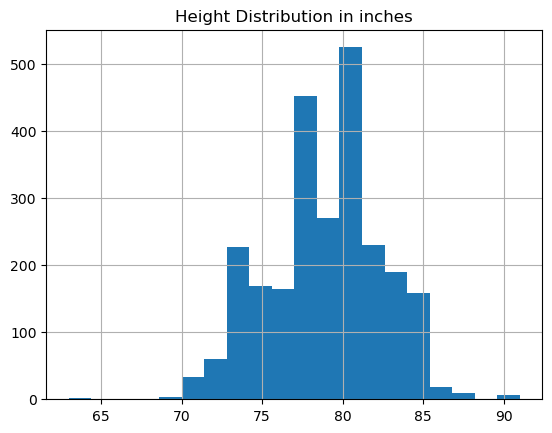

In [38]:
# Distribution of Height Variable
graph = df['HEIGHT_IN'].hist(bins=20)
graph.set_title('Height Distribution in inches')
plt.show()

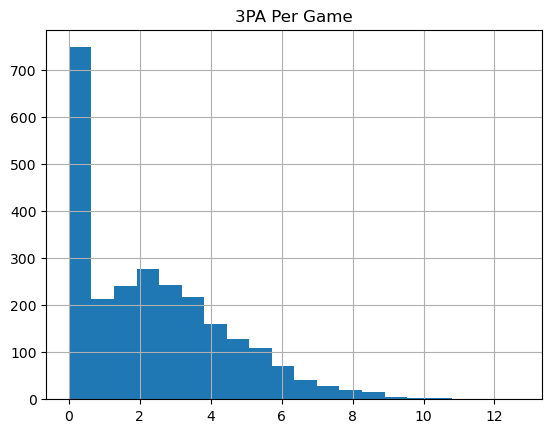

In [39]:
# Distribution of 3PA Per Game Variable
graph = df['FG3A_PER_GAME'].hist(bins=20)
graph.set_title('3PA Per Game')
plt.show()

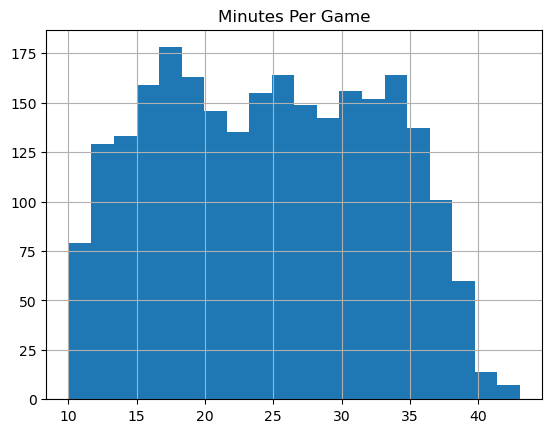

In [40]:
# Distribution of Minutes Per Game Variable
graph = df['MPG'].hist(bins=20)
graph.set_title('Minutes Per Game')
plt.show()

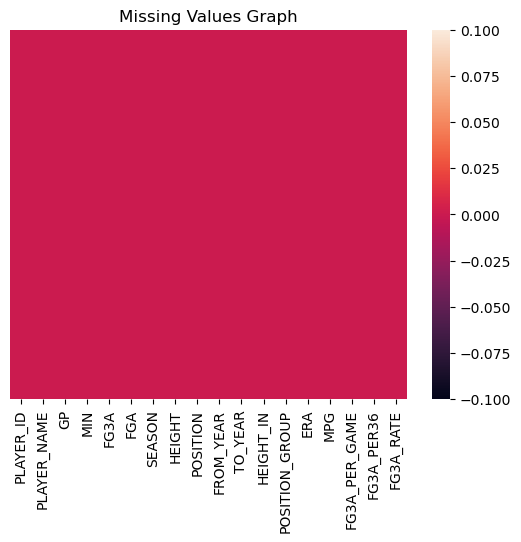

In [41]:
# Missing Values Graph
sns.heatmap(df.isnull(), yticklabels=False)
plt.title('Missing Values Graph')
plt.show()

The heatmap shown above has a color for missing data and another color for when the data is not missing. Therefore, the uniform color demonstrates that every single cell in the dataset has a value (no missing data).

## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



#### Section 1 of EDA - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [ ]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

#### Section 2 of EDA if you need it  - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [ ]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

## Ethics

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Team Expectations 

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Project Timeline Proposal

Instructions: Replace this with your timeline.  **PLEASE UPDATE your Timeline!** No battle plan survives contact with the enemy, so make sure we understand how your plans have changed.  Also if you have lost points on the previous checkpoint fix them